<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>Smart Parking Space Counter</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">Automated Computer Vision Detection, Thresholding & Occupancy Analytics</span>
</div>

<a id="project-overview"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">📌 Project Overview & Objectives</span>

* **Goal:** Automatically determine which parking bays are vacant (FREE) and which are occupied (OCCUPIED) using live camera footage.
* **Approach:** Classical Computer Vision and morphological processing (Thresholding + Pixel Counting) rather than heavy deep neural networks.


---

# Table of Contents 

1. [Setup & Dependencies](#1-setup)
2. [Loading Calibration Data & Reference Image](#2-data)
   - 2.1 [Key Notes & Coordinate System](#21-coords)
3. [Computer Vision Preprocessing Pipeline](#3-pipeline)
   - 3.1 [Sequential Transformation Stages](#31-stages)
   - 3.2 [Why Adaptive Thresholding Instead of Global](#32-adaptive)
4. [In-Depth Comparison: Free Spot vs. Occupied Spot](#4-comparison)
   - 4.1 [Core Intuitive Principles & Feature Separation](#41-principles)
5. [Statistical Distribution & Decision Threshold Calibration](#5-distribution)
   - 5.1 [Decision Rule & Safety Margins](#51-decision)
6. [Per-Slot Occupancy Analysis Across All 69 Spots](#6-perslot)
   - 6.1 [Observations & Classification Boundary](#61-observations)
7. [Current Parking Lot Occupancy Summary](#7-summary)
   - 7.1 [Summary Metrics & Capacity Utilization](#71-metrics)
8. [Temporal Video Analysis: Tracking Occupancy Over Time](#8-temporal)
   - 8.1 [Video Properties & Methodology](#81-methodology)
9. [Spatial Layout & Occupancy Map](#9-spatial)
   - 9.1 [Practical Value of Spatial Mapping](#91-value)
10. [Modular Function Verification & Live Overlay](#10-modular)
    - 10.1 [Production Verification & Rendering](#101-verification)
---


<a id="1-setup"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Setup & Dependencies</span>

In [13]:
import os
import sys
import pickle
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Add project root and src to sys.path
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Color palette definition using simple basic colors (avoiding hex codes)
COLOR_FREE = 'green'
COLOR_OCCUPIED = 'red'
COLOR_PRIMARY = 'blue'
COLOR_SECONDARY = 'orange'
COLOR_NEUTRAL = 'gray'

print("Setup completed successfully!")
print(f"Project Root Directory: {PROJECT_ROOT}")


Setup completed successfully!
Project Root Directory: E:\001_Github_Repo_all\parking-occupancy-detection


<a id="2-data"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Loading Calibration Data & Reference Image</span>


The detector relies on pre-calibrated bounding boxes for each parking spot. Each parking spot is defined by:
1. **Top-Left Corner:** Coordinate pair $(x, y)$ in pixels.
2. **Width & Height:** Standardized parking box dimensions: $107 \text{ px} \times 48 \text{ px}$.

<a id="21-coords"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.1 Key Notes & Coordinate System</span>


* The coordinates are stored in `asset/CarParkPos` created via the interactive `src/ParkingSpacePicker.py` tool.
* OpenCV reads images in **BGR** (Blue-Green-Red) format by default, whereas Matplotlib displays in **RGB**. We use `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` for accurate color rendering in Matplotlib.


In [14]:
# Define asset paths
pos_path = PROJECT_ROOT / 'asset' / 'CarParkPos'
img_path = PROJECT_ROOT / 'asset' / 'carParkImg.png'
video_path = PROJECT_ROOT / 'asset' / 'carPark.mp4'

# Load parking positions
with open(pos_path, 'rb') as f:
    pos_list = pickle.load(f)

# Load reference image
ref_img_bgr = cv2.imread(str(img_path))
ref_img_rgb = cv2.cvtColor(ref_img_bgr, cv2.COLOR_BGR2RGB)

# Parking slot dimensions
SLOT_WIDTH = 107
SLOT_HEIGHT = 48

print(f"Total Parking Spots Loaded: {len(pos_list)}")
print(f"Reference Image Dimensions: {ref_img_bgr.shape[1]} x {ref_img_bgr.shape[0]} (Width x Height)")
print(f"Standard Slot Size: {SLOT_WIDTH} px width x {SLOT_HEIGHT} px height")
print(f"First 5 Sample Coordinates: {pos_list[:5]}")


Total Parking Spots Loaded: 69
Reference Image Dimensions: 1100 x 720 (Width x Height)
Standard Slot Size: 107 px width x 48 px height
First 5 Sample Coordinates: [(401, 238), (752, 377), (55, 100), (56, 146), (50, 241)]


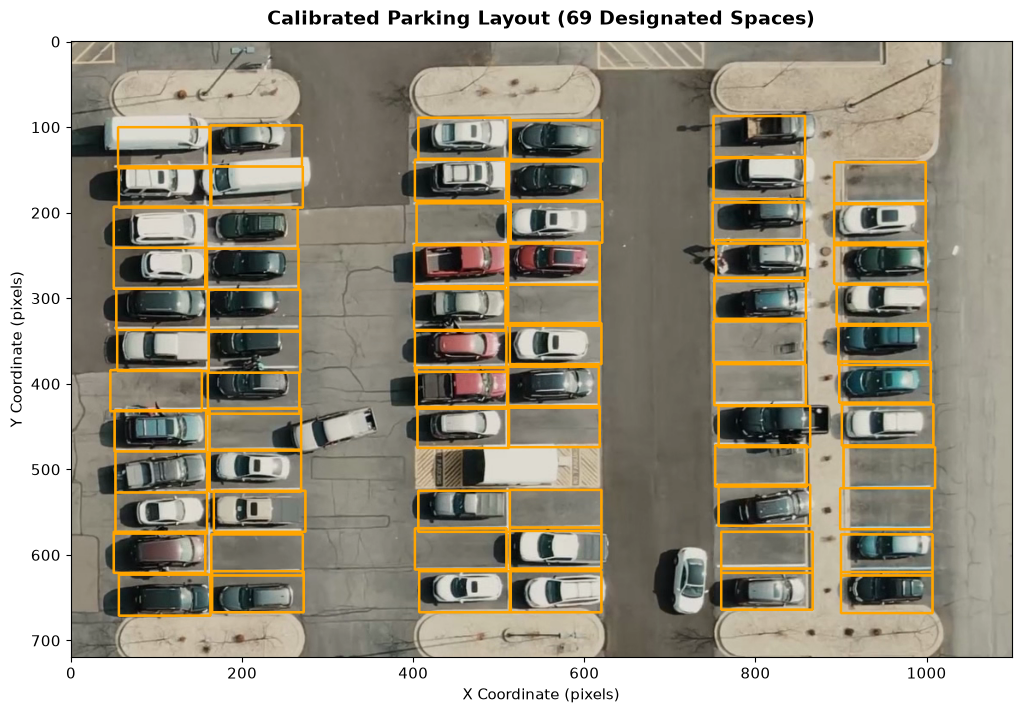

In [15]:
# Overlay all parking slots on reference image
annotated_img = ref_img_rgb.copy()

for idx, (x, y) in enumerate(pos_list):
    # Draw slot bounding box
    cv2.rectangle(
        annotated_img,
        (x, y),
        (x + SLOT_WIDTH, y + SLOT_HEIGHT),
        (255, 165, 0),  # Orange outline in RGB
        2
    )

plt.figure(figsize=(14, 8))
plt.imshow(annotated_img)
plt.title(f"Calibrated Parking Layout ({len(pos_list)} Designated Spaces)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("X Coordinate (pixels)")
plt.ylabel("Y Coordinate (pixels)")
plt.grid(False)
plt.show()


<a id="3-pipeline"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Computer Vision Preprocessing Pipeline</span>


To differentiate an empty parking space from an occupied one, we transform the raw color image into a binary edge representation. 

<a id="31-stages"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.1 Sequential Transformation Stages</span>


The image processing pipeline comprises **5 sequential stages**:
1. **Grayscale Conversion (`cv2.cvtColor`):** Eliminates 3 color channels (BGR) down to 1 luminance channel, stripping lighting color bias and speeding up calculations.
2. **Gaussian Blur (`cv2.GaussianBlur`):** Convolves the image with a $(3 \times 3)$ Gaussian kernel to suppress high-frequency sensor noise and camera artifacts.
3. **Adaptive Thresholding (`cv2.adaptiveThreshold`):** Computes a local threshold for each $25 \times 25$ pixel neighborhood using Gaussian weighting. This isolates edges even when shadows or uneven sunlight fall across the lot.
4. **Median Blur (`cv2.medianBlur`):** Replaces each pixel with the median of its neighbors. This eliminates isolated salt-and-pepper noise specks.
5. **Morphological Dilation (`cv2.dilate`):** Expands white foreground pixels using a $(3 \times 3)$ structuring element, merging fragmented edges of cars into solid connected regions.

<a id="32-adaptive"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.2 Why Adaptive Thresholding Instead of Global Thresholding?</span>


* **Global Thresholding (e.g. Otsu's method):** Applies a single fixed threshold to the entire image. In outdoor parking lots, sunlight and shadows cause dark regions where cars become invisible or bright pavement that creates false edges.
* **Adaptive Thresholding:** Calculates the threshold locally for every pixel neighborhood, preserving car outlines and road contrast consistently across both shaded and sunny zones.


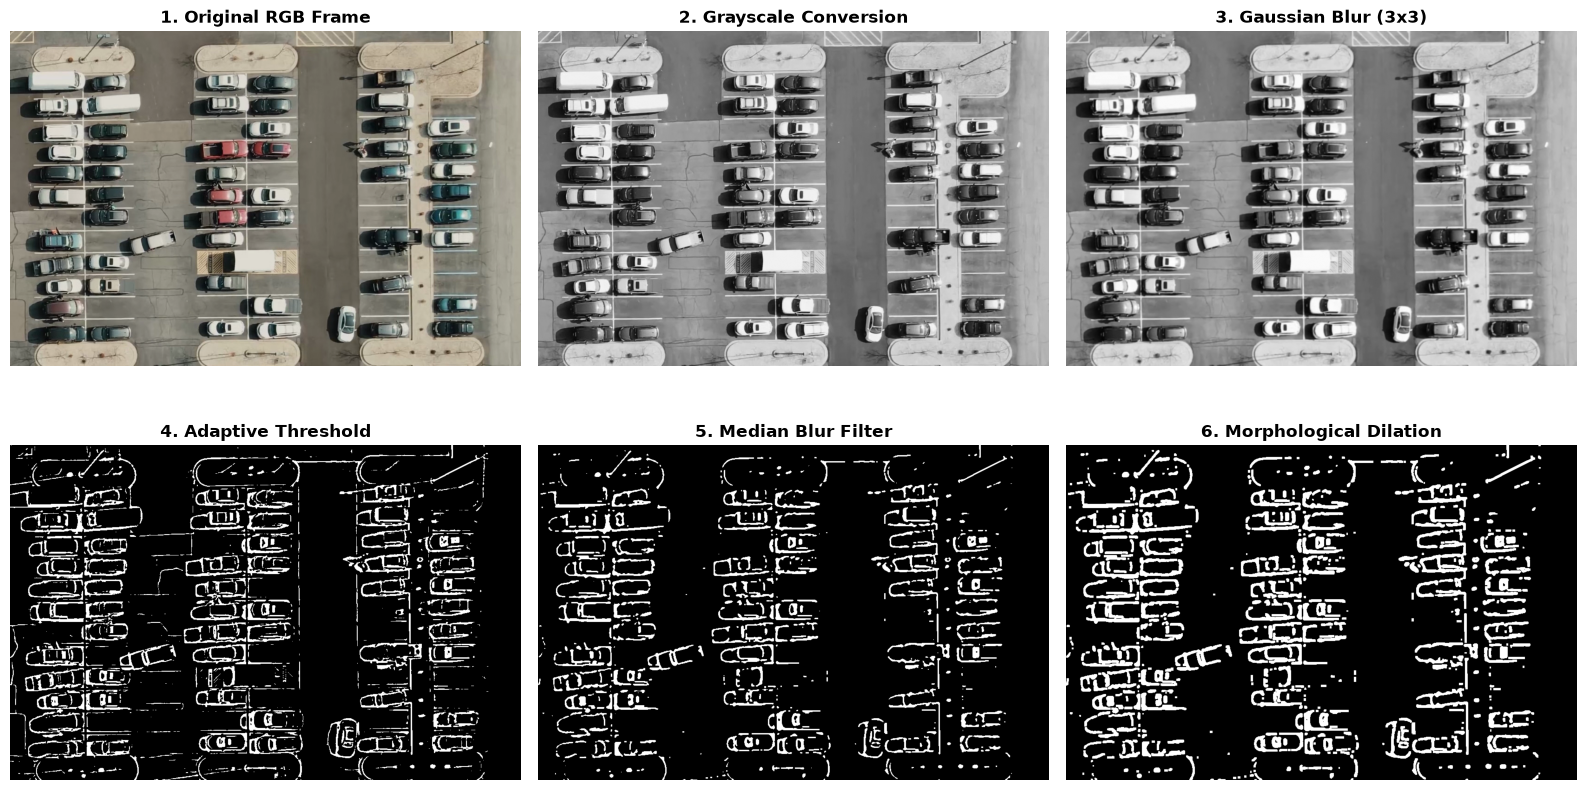

In [16]:
# Execute each step of the pipeline step-by-step
step1_gray = cv2.cvtColor(ref_img_bgr, cv2.COLOR_BGR2GRAY)
step2_blur = cv2.GaussianBlur(step1_gray, (3, 3), 1)
step3_thresh = cv2.adaptiveThreshold(
    step2_blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    25,
    16
)
step4_median = cv2.medianBlur(step3_thresh, 5)
kernel = np.ones((3, 3), np.uint8)
step5_dilate = cv2.dilate(step4_median, kernel, iterations=1)

# Plot all 6 pipeline stages in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

stages = [
    (ref_img_rgb, "1. Original RGB Frame", None),
    (step1_gray, "2. Grayscale Conversion", "gray"),
    (step2_blur, "3. Gaussian Blur (3x3)", "gray"),
    (step3_thresh, "4. Adaptive Threshold", "gray"),
    (step4_median, "5. Median Blur Filter", "gray"),
    (step5_dilate, "6. Morphological Dilation", "gray"),
]

for ax, (img_stage, title, cmap) in zip(axes.flatten(), stages):
    ax.imshow(img_stage, cmap=cmap)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


<a id="4-comparison"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. In-Depth Comparison: Free Spot vs. Occupied Spot</span>


Why does pixel counting work so reliably? Let's crop two specific parking spots from the reference image:
* **Empty Spot:** Smooth asphalt road surface.
* **Occupied Spot:** Vehicle with edges, windshield reflections, headlights, and tires.

<a id="41-principles"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.1 Core Intuitive Principles & Feature Separation</span>


* **Empty Parking Spot:** The asphalt pavement is uniform with minimal contrast changes. Consequently, the adaptive threshold produces very few white edge pixels.
* **Occupied Parking Spot:** The vehicle contains sharp contours, metallic reflections, glass edges, and grille patterns. This produces a massive concentration of white pixels.
* **Measurement:** We use `cv2.countNonZero(crop)` to quantify the total number of white pixels in each parking box.


Selected Empty Spot: Slot #28 at (164, 576) -> Non-Zero Pixels: 99
Selected Occupied Spot: Slot #50 at (754, 232) -> Non-Zero Pixels: 2294


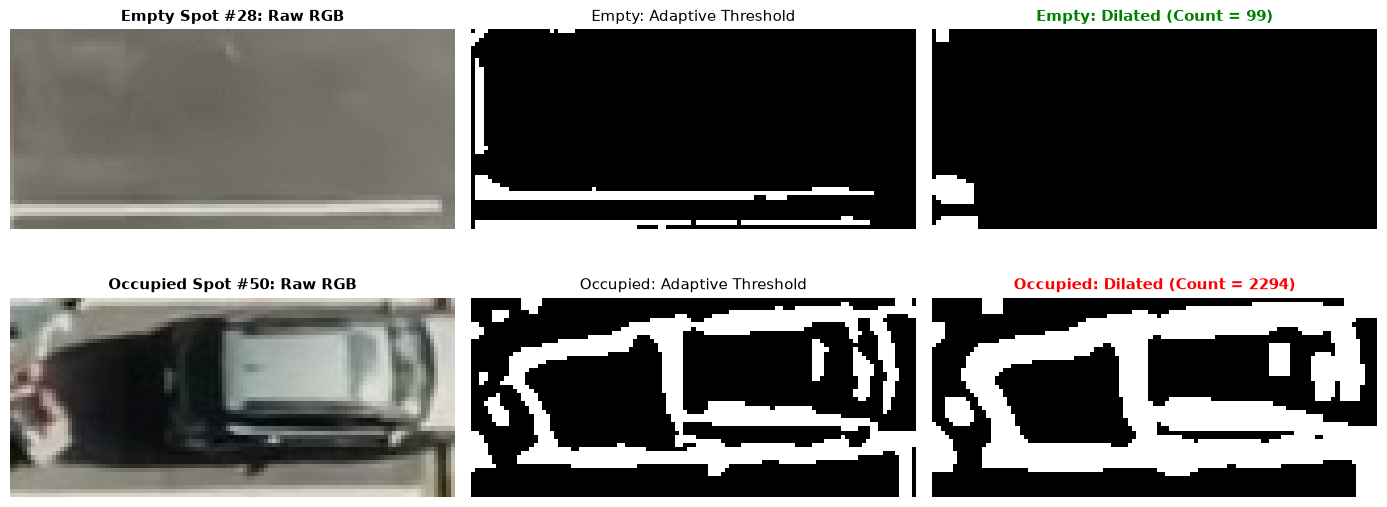

In [17]:
# Let's find an empty spot and an occupied spot
# We examine all spots to pick a clear empty spot and a clear occupied spot
slot_counts = []
for idx, (x, y) in enumerate(pos_list):
    crop = step5_dilate[y : y + SLOT_HEIGHT, x : x + SLOT_WIDTH]
    c = cv2.countNonZero(crop)
    slot_counts.append((idx, x, y, c))

# Empty spot has low count; occupied has high count
empty_sample = min(slot_counts, key=lambda item: item[3])
occupied_sample = max(slot_counts, key=lambda item: item[3])

empty_idx, ex, ey, empty_count = empty_sample
occ_idx, ox, oy, occ_count = occupied_sample

print(f"Selected Empty Spot: Slot #{empty_idx + 1} at ({ex}, {ey}) -> Non-Zero Pixels: {empty_count}")
print(f"Selected Occupied Spot: Slot #{occ_idx + 1} at ({ox}, {oy}) -> Non-Zero Pixels: {occ_count}")

# Crop images for both spots
empty_crop_rgb = ref_img_rgb[ey : ey + SLOT_HEIGHT, ex : ex + SLOT_WIDTH]
empty_crop_thresh = step3_thresh[ey : ey + SLOT_HEIGHT, ex : ex + SLOT_WIDTH]
empty_crop_dilate = step5_dilate[ey : ey + SLOT_HEIGHT, ex : ex + SLOT_WIDTH]

occ_crop_rgb = ref_img_rgb[oy : oy + SLOT_HEIGHT, ox : ox + SLOT_WIDTH]
occ_crop_thresh = step3_thresh[oy : oy + SLOT_HEIGHT, ox : ox + SLOT_WIDTH]
occ_crop_dilate = step5_dilate[oy : oy + SLOT_HEIGHT, ox : ox + SLOT_WIDTH]

# Plot side-by-side comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

# Row 1: Empty Spot
axes[0, 0].imshow(empty_crop_rgb)
axes[0, 0].set_title(f"Empty Spot #{empty_idx + 1}: Raw RGB", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(empty_crop_thresh, cmap='gray')
axes[0, 1].set_title("Empty: Adaptive Threshold", fontsize=11)
axes[0, 1].axis('off')

axes[0, 2].imshow(empty_crop_dilate, cmap='gray')
axes[0, 2].set_title(f"Empty: Dilated (Count = {empty_count})", fontsize=11, color=COLOR_FREE, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Occupied Spot
axes[1, 0].imshow(occ_crop_rgb)
axes[1, 0].set_title(f"Occupied Spot #{occ_idx + 1}: Raw RGB", fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(occ_crop_thresh, cmap='gray')
axes[1, 1].set_title("Occupied: Adaptive Threshold", fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].imshow(occ_crop_dilate, cmap='gray')
axes[1, 2].set_title(f"Occupied: Dilated (Count = {occ_count})", fontsize=11, color=COLOR_OCCUPIED, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


<a id="5-distribution"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Statistical Distribution & Decision Threshold Calibration</span>


How was the threshold of **900 pixels** chosen? Let's analyze the non-zero pixel count distribution across all 69 parking spots.

<a id="51-decision"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Decision Rule & Safety Margins</span>


* $\text{Pixel Count} < 900 \implies$ **FREE** (Green)
* $\text{Pixel Count} \ge 900 \implies$ **OCCUPIED** (Red)

### 📌 Key Insights from Distribution
* The distribution is **bimodal** (has two clear peaks):
  * **Low-count cluster (< 700 pixels):** Represents clear road asphalt with virtually no sharp edges.
  * **High-count cluster (> 1100 pixels):** Represents vehicles full of edges, grilles, lights, and windows.
* The threshold $900$ sits conveniently in the valley between these two clusters, providing a wide safety margin against false positives and false negatives.


Summary Statistics for Pixel Counts:
count      69.00
mean     1407.62
std       643.25
min        99.00
25%      1279.00
50%      1610.00
75%      1853.00
max      2294.00
Name: Pixel_Count, dtype: float64


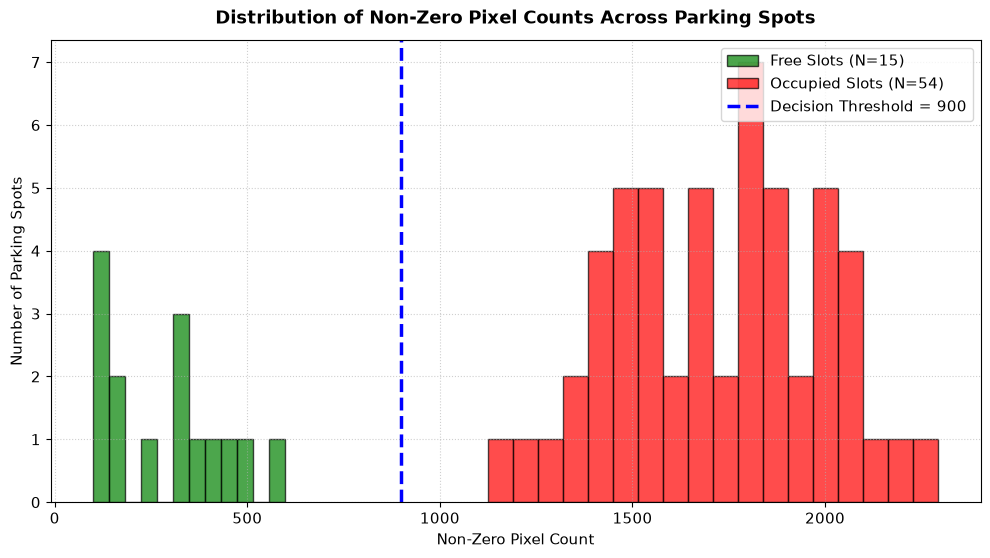

In [18]:
# Build dataframe of all parking slots
records = []
for idx, (x, y) in enumerate(pos_list):
    crop = step5_dilate[y : y + SLOT_HEIGHT, x : x + SLOT_WIDTH]
    count = cv2.countNonZero(crop)
    is_free = count < 900
    status = "Free" if is_free else "Occupied"
    records.append({
        "Slot_ID": idx + 1,
        "X": x,
        "Y": y,
        "Pixel_Count": count,
        "Status": status,
        "Is_Free": is_free
    })

df_slots = pd.DataFrame(records)

print(f"Summary Statistics for Pixel Counts:")
print(df_slots['Pixel_Count'].describe().round(2))

# Plot Histogram and Distribution
plt.figure(figsize=(12, 6))

free_counts = df_slots[df_slots['Status'] == 'Free']['Pixel_Count']
occ_counts = df_slots[df_slots['Status'] == 'Occupied']['Pixel_Count']

plt.hist(free_counts, bins=12, color=COLOR_FREE, alpha=0.7, edgecolor='black', label=f'Free Slots (N={len(free_counts)})')
plt.hist(occ_counts, bins=18, color=COLOR_OCCUPIED, alpha=0.7, edgecolor='black', label=f'Occupied Slots (N={len(occ_counts)})')

# Threshold line
plt.axvline(900, color=COLOR_PRIMARY, linestyle='--', linewidth=2.5, label='Decision Threshold = 900')

plt.title("Distribution of Non-Zero Pixel Counts Across Parking Spots", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Non-Zero Pixel Count")
plt.ylabel("Number of Parking Spots")
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


<a id="6-perslot"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Per-Slot Occupancy Analysis Across All 69 Spots</span>


Let's inspect each individual parking slot in sequence to verify how each spot scores relative to the decision threshold.

<a id="61-observations"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Observations & Slot Classification</span>


* Slots with counts below 900 are shown in **green** (Free).
* Slots with counts at or above 900 are shown in **red** (Occupied).
* The horizontal blue dashed line marks the exact classification boundary.


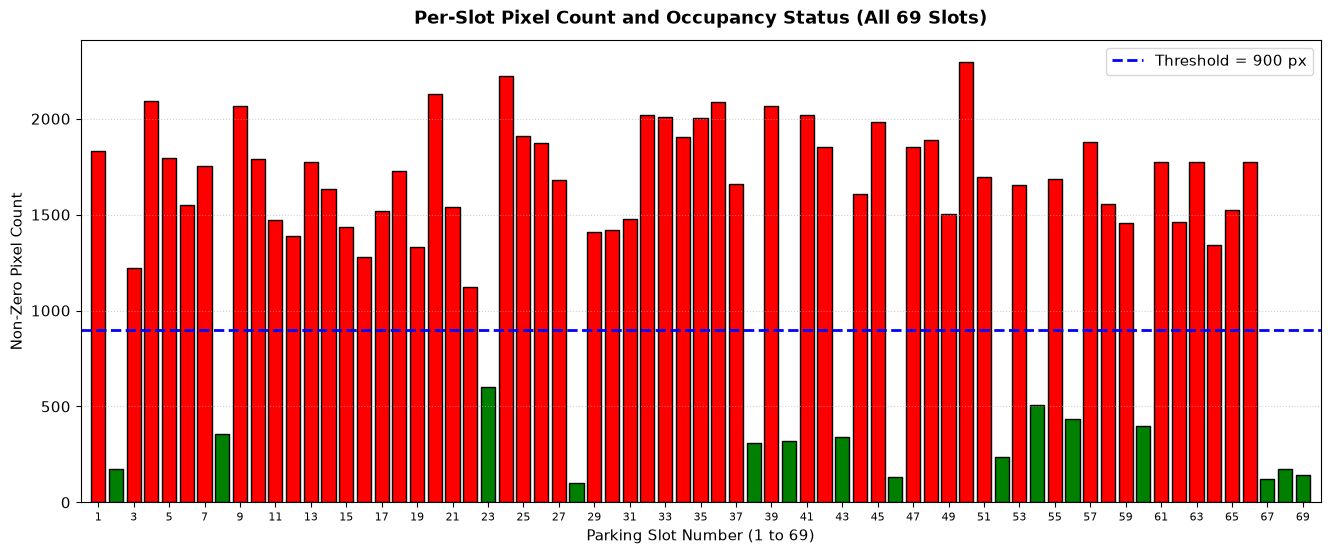

In [19]:
plt.figure(figsize=(16, 6))

# Assign simple colors based on status
bar_colors = [COLOR_FREE if count < 900 else COLOR_OCCUPIED for count in df_slots['Pixel_Count']]

plt.bar(df_slots['Slot_ID'], df_slots['Pixel_Count'], color=bar_colors, edgecolor='black', width=0.8)
plt.axhline(900, color=COLOR_PRIMARY, linestyle='--', linewidth=2, label='Threshold = 900 px')

plt.title("Per-Slot Pixel Count and Occupancy Status (All 69 Slots)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Parking Slot Number (1 to 69)")
plt.ylabel("Non-Zero Pixel Count")
plt.xlim(0, 70)
plt.xticks(range(1, 70, 2), rotation=0, fontsize=8)
plt.legend(loc='upper right')
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()


<a id="7-summary"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Current Parking Lot Occupancy Summary</span>


Let's compute the overall parking capacity, available spaces, and occupancy rate for the reference frame.

<a id="71-metrics"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.1 Summary Metrics & Capacity Utilization</span>


* **Total Capacity:** 69 parking spaces.
* **Available Spaces:** 15 free bays (21.7%).
* **Occupied Spaces:** 54 parked vehicles (78.3%).
* **Occupancy Rate:** 78.3%, indicating high parking facility utilization.


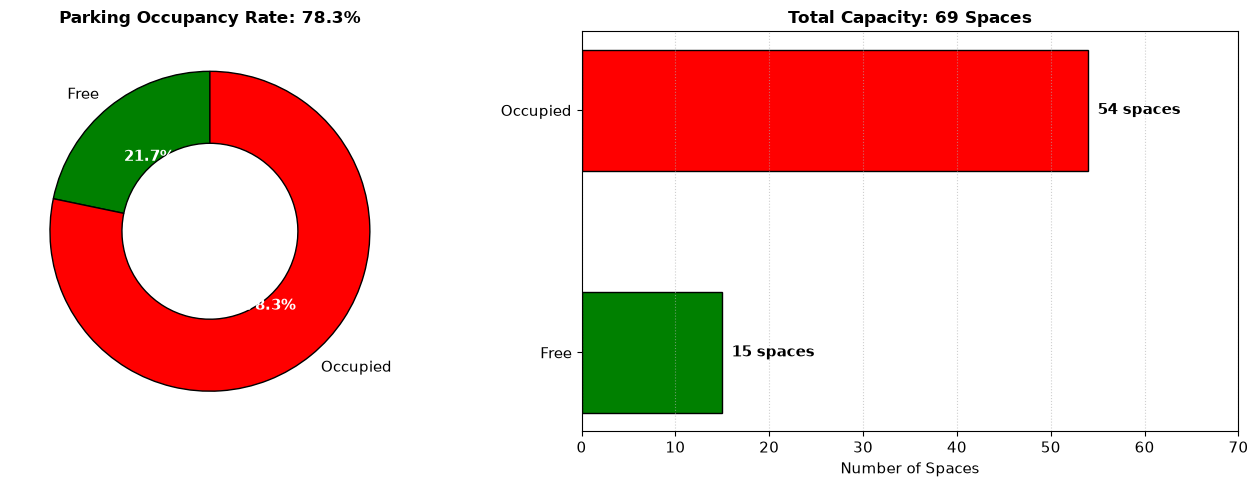

In [20]:
# Summary counts
free_total = int(df_slots['Is_Free'].sum())
occ_total = len(df_slots) - free_total
occ_rate = (occ_total / len(df_slots)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut Chart
categories = ['Free', 'Occupied']
counts = [free_total, occ_total]
colors = [COLOR_FREE, COLOR_OCCUPIED]

wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=categories,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='black')
)
for text in autotexts:
    text.set_color('white')
    text.set_fontweight('bold')
axes[0].set_title(f"Parking Occupancy Rate: {occ_rate:.1f}%", fontsize=12, fontweight='bold')

# Horizontal Bar Chart
axes[1].barh(categories, counts, color=colors, edgecolor='black', height=0.5)
for idx, val in enumerate(counts):
    axes[1].text(val + 1, idx, f"{val} spaces", va='center', fontweight='bold')

axes[1].set_xlim(0, 70)
axes[1].set_xlabel("Number of Spaces")
axes[1].set_title(f"Total Capacity: {len(df_slots)} Spaces", fontsize=12, fontweight='bold')
axes[1].grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


<a id="8-temporal"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Temporal Video Analysis: Tracking Occupancy Over Time</span>


Now let's process the video `asset/carPark.mp4`. We will sample video frames across the sequence, apply our computer vision preprocessing pipeline to each frame, and track how the number of free vs. occupied parking spaces evolves over time.

<a id="81-methodology"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.1 Video Properties & Methodology</span>


* **Total Video Frames:** 679 frames at 24 frames per second (~28.3 seconds of continuous surveillance).
* **Sampling Rate:** Every 20 frames (~0.83 seconds real-time), yielding 34 temporal observation points.
* **Measurement:** We count the number of Free and Occupied spaces at each temporal checkpoint.


In [21]:
# Process video and record temporal metrics
cap = cv2.VideoCapture(str(video_path))
fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

temporal_data = []
frame_idx = 0
sample_interval = 20

while True:
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    if frame_idx % sample_interval == 0:
        # Preprocess frame
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (3, 3), 1)
        thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY_INV, 25, 16)
        median = cv2.medianBlur(thresh, 5)
        dilated = cv2.dilate(median, kernel, iterations=1)

        # Count free spaces
        free_count = 0
        for x, y in pos_list:
            slot_crop = dilated[y : y + SLOT_HEIGHT, x : x + SLOT_WIDTH]
            if cv2.countNonZero(slot_crop) < 900:
                free_count += 1
        
        occ_count = len(pos_list) - free_count
        timestamp_sec = frame_idx / fps

        temporal_data.append({
            "Frame": frame_idx,
            "Timestamp_Sec": round(timestamp_sec, 2),
            "Free_Spaces": free_count,
            "Occupied_Spaces": occ_count,
            "Occupancy_Rate": round((occ_count / len(pos_list)) * 100, 1)
        })

    frame_idx += 1

cap.release()

df_temporal = pd.DataFrame(temporal_data)
print(f"Sampled {len(df_temporal)} frames across video duration ({df_temporal['Timestamp_Sec'].max()} seconds).")
df_temporal.head()


Sampled 34 frames across video duration (27.5 seconds).


,Frame,Timestamp_Sec,Free_Spaces,Occupied_Spaces,Occupancy_Rate
0,0,0.00,12,57,82.6
1,20,0.83,12,57,82.6
2,40,1.67,12,57,82.6
3,60,2.50,12,57,82.6
4,80,3.33,12,57,82.6


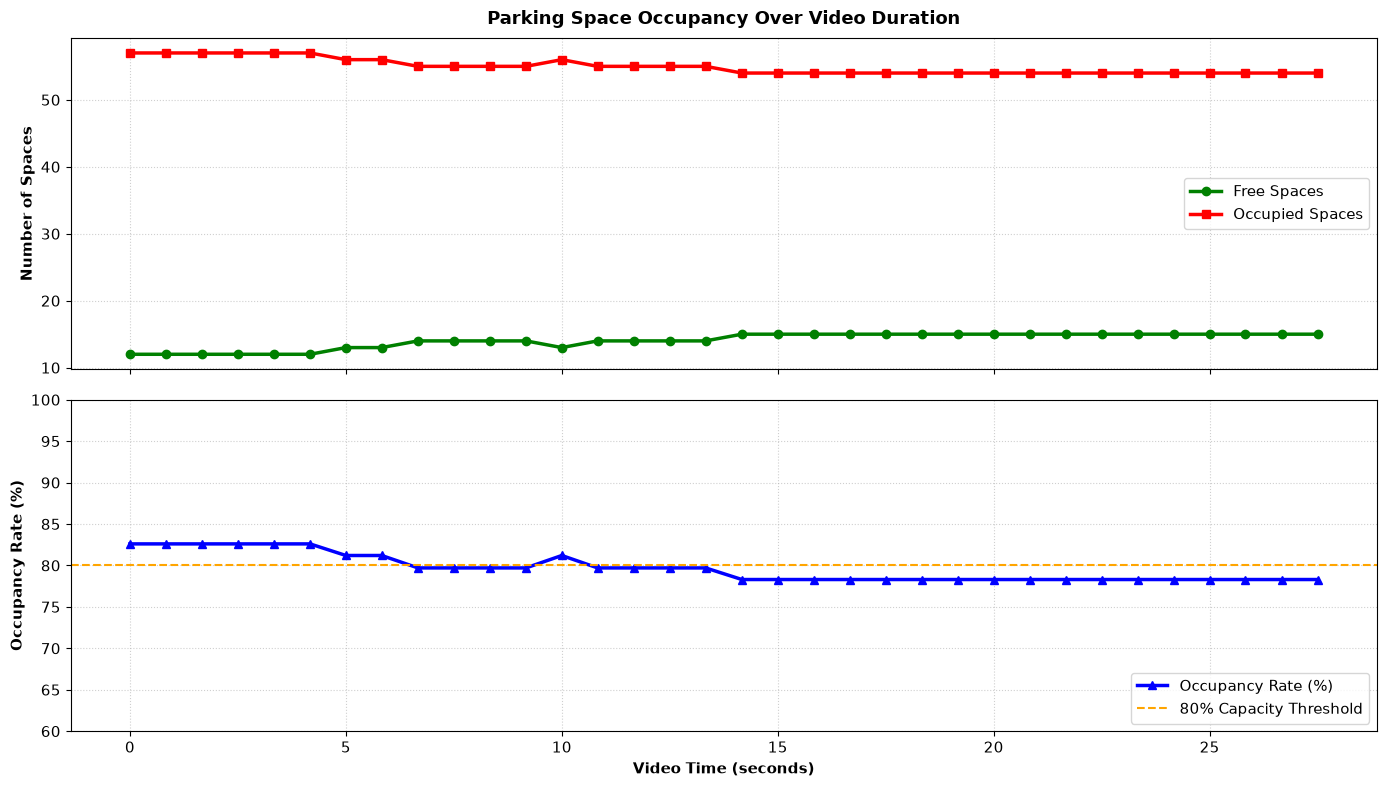

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Free vs. Occupied Line Chart
axes[0].plot(df_temporal['Timestamp_Sec'], df_temporal['Free_Spaces'], 
             color=COLOR_FREE, marker='o', linewidth=2.5, label='Free Spaces')
axes[0].plot(df_temporal['Timestamp_Sec'], df_temporal['Occupied_Spaces'], 
             color=COLOR_OCCUPIED, marker='s', linewidth=2.5, label='Occupied Spaces')
axes[0].set_ylabel("Number of Spaces", fontweight='bold')
axes[0].set_title("Parking Space Occupancy Over Video Duration", fontsize=13, fontweight='bold', pad=10)
axes[0].legend(loc='center right', frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Occupancy Rate Percentage
axes[1].plot(df_temporal['Timestamp_Sec'], df_temporal['Occupancy_Rate'], 
             color=COLOR_PRIMARY, marker='^', linewidth=2.5, label='Occupancy Rate (%)')
axes[1].axhline(80, color=COLOR_SECONDARY, linestyle='--', label='80% Capacity Threshold')
axes[1].set_ylabel("Occupancy Rate (%)", fontweight='bold')
axes[1].set_xlabel("Video Time (seconds)", fontweight='bold')
axes[1].set_ylim(60, 100)
axes[1].legend(loc='lower right', frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


<a id="9-spatial"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Spatial Layout & Occupancy Map</span>


Let's visualize the spatial distribution of the parking slots across the lot. By plotting each slot at its calibrated $(x, y)$ coordinate, we can see where available spots are clustered.

<a id="91-value"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">9.1 Practical Value of Spatial Mapping</span>


* **Dynamic Wayfinding:** Drivers can be directed to the exact row or zone with available slots.
* **Row-Level Utilization:** Facility managers can identify under-utilized sections or congested aisles.


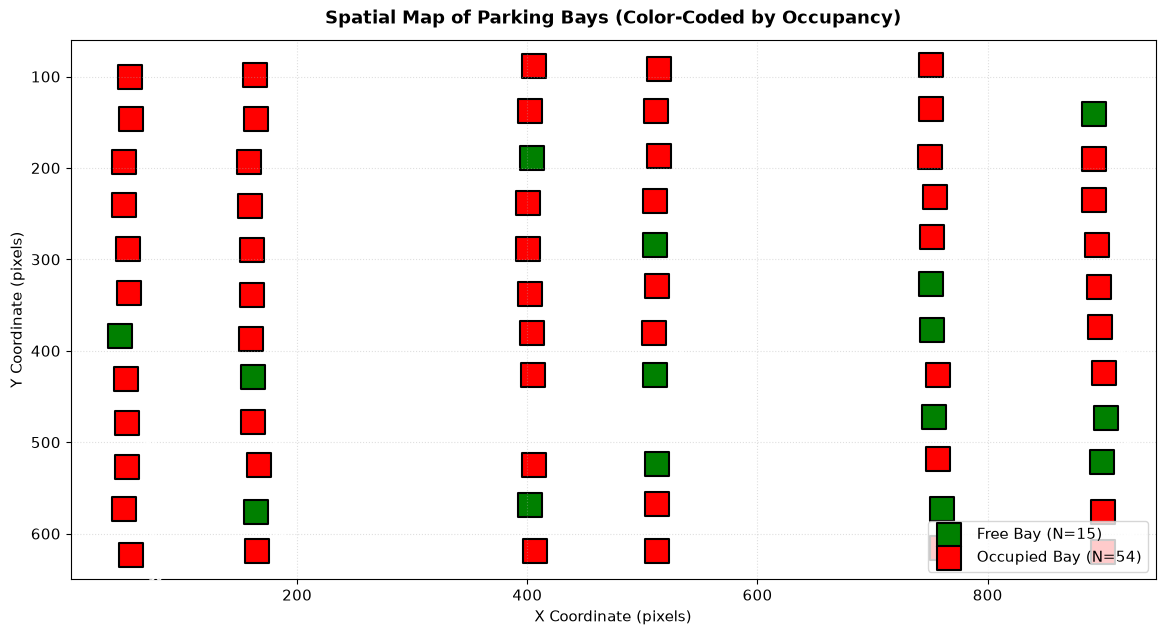

In [25]:
plt.figure(figsize=(14, 7))

# Plot free spots in green, occupied in red
free_df = df_slots[df_slots['Status'] == 'Free']
occ_df = df_slots[df_slots['Status'] == 'Occupied']

plt.scatter(free_df['X'], free_df['Y'], color=COLOR_FREE, s=300, marker='s', edgecolors='black', 
            linewidths=1.5, label=f'Free Bay (N={len(free_df)})')
plt.scatter(occ_df['X'], occ_df['Y'], color=COLOR_OCCUPIED, s=300, marker='s', edgecolors='black', 
            linewidths=1.5, label=f'Occupied Bay (N={len(occ_df)})')

# Label slot IDs
for _, row in df_slots.iterrows():
    plt.text(row['X'] + 15, row['Y'] + 28, str(int(row['Slot_ID'])), 
             fontsize=7, color='white', fontweight='bold')

# Invert Y-axis because image coordinates start at top-left (0,0)
plt.gca().invert_yaxis()
plt.title("Spatial Map of Parking Bays (Color-Coded by Occupancy)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("X Coordinate (pixels)")
plt.ylabel("Y Coordinate (pixels)")
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()


<a id="10-modular"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">10. Modular Function Verification & Live Overlay</span>


Let's verify that the modular functions in `src/counter_logic.py` work seamlessly:
* `preprocess_image(frame)`
* `check_parking_spaces(img_processed, img_display, pos_list)`
* `draw_dashboard_banner(img, free_count, total_count)`

<a id="101-verification"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">10.1 Production Verification & Rendering</span>


Let's process the reference image using these production functions and display the resulting annotated frame.


[INFO] Loaded 69 parking space coordinates from CarParkPos
Detector Verification: 15 Free / 69 Total spaces.


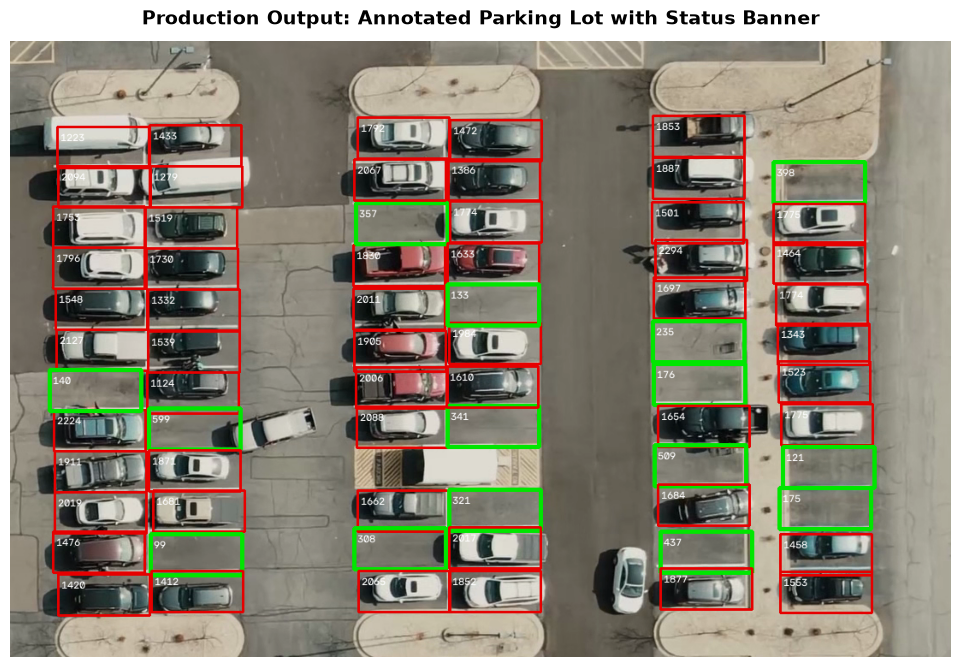

In [24]:
from src.counter_logic import (
    preprocess_image, 
    check_parking_spaces, 
    load_parking_positions, 
    SLOT_WIDTH, 
    SLOT_HEIGHT, 
    PIXEL_THRESHOLD
    )

# Test modular functions
positions = load_parking_positions(pos_path)
test_frame = cv2.imread(str(img_path))

# Run production preprocessing
processed_binary = preprocess_image(test_frame)

# Run production classifier and overlay renderer
free_count, total_count, slot_details = check_parking_spaces(
    processed_binary,
    test_frame,
    positions,
    width=SLOT_WIDTH,
    height=SLOT_HEIGHT,
    threshold=PIXEL_THRESHOLD)

print(f"Detector Verification: {free_count} Free / {total_count} Total spaces.")

# Convert BGR display frame to RGB for Matplotlib
final_display_rgb = cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 8))
plt.imshow(final_display_rgb)
plt.title("Production Output: Annotated Parking Lot with Status Banner", fontsize=14, fontweight='bold', pad=12)
plt.axis('off')
plt.show()
